# Intern Task 1: Dataset Understanding, Edit Analysis and Strategy Readiness

## Role of this notebook

This is the **student version** of Stage 1. Its code cells are intentionally
empty. You must write, run and explain the analysis yourself.

Stage 1 establishes whether the multilingual simplification data are valid,
balanced and suitable for the later classifier and explainability experiments.
It does not train the final model and it does not generate model attributions.

Your work must produce:

1. a reproducible data-integrity and split audit;
2. exact complex-versus-simple quartile and IQR statistics for every language;
3. alignment, edit-operation, deletion and insertion analyses;
4. linguistic descriptions using spaCy with UDPipe dependencies;
5. strategy statistics when completed human labels are available;
6. focused robustness checks that protect the later XAI conclusions;
7. publication-ready tables, figures and written interpretation.

Do not modify the processed source files. Save all derived outputs under
`reports/data_statistics/`.

## Stage 1 scope

### Required now

- data integrity, duplicates, missingness and leakage;
- composition by language, collection, document and split;
- complex versus simple Q1, median, Q3 and IQR for every language;
- paired length and linguistic-change statistics;
- source and target alignment coverage;
- DELETE, INSERT, SUBSTITUTE, SPLIT, MERGE, COMPLEX and reordering;
- deletion and insertion span length, position and linguistic type;
- split comparability;
- effect sizes, confidence intervals and corrected comparisons;
- document-aware and alignment-sensitivity checks where the data permit.

### Conditional within Stage 1

- spaCy–UDPipe linguistic annotation requires the language models to be
  installed in Colab;
- strategy frequency, co-occurrence and edit–strategy associations must run
  only on pairs marked `complete` or `adjudicated`;
- inter-annotator agreement requires independently annotated overlap.

Blank strategy cells must never be interpreted as strategy absence.

## Important statistical principle

The **sentence pair** is the primary unit of analysis.

The token-level file is useful for counting and visualising edit operations, but tokens from the same sentence are not independent observations. Do not run inferential tests that treat all source tokens as independent. Statistical tests on edit behaviour should use one aggregated record per sentence pair, or an explicitly justified hierarchical model.

Length reduction is only a surface indicator. Do not claim that a shorter sentence is necessarily simpler or better.

## Research questions

Answer the following questions.

### RQ1. Dataset composition
- How many sentence pairs, classifier instances, source tokens, languages, collections and documents are present?
- Is the dataset balanced across languages and collections?
- Are there missing values, duplicated identifiers or inconsistent labels?

### RQ2. Length change during simplification
- How do source and target sentence lengths differ overall and by language?
- What are the absolute and proportional length changes?
- How often is the target shorter, equal in length or longer than the source?

### RQ3. Alignment characteristics
- What are the source and target alignment coverage distributions?
- How many alignment links occur per pair?
- Do alignment coverage and link density differ across languages?
- Are low-coverage pairs concentrated in particular languages or collections?

### RQ4. Observed human edits
- How frequent are KEEP, DELETE, SUBSTITUTE, SPLIT, MERGE and COMPLEX operations?
- How do operation profiles differ by language?
- What proportion of content tokens is edited in each pair?
- How often do reordering and content edits occur?

### RQ5. Relationships between simplification indicators
- Is length reduction associated with content edit rate?
- Is alignment coverage associated with the measured edit rate?
- Are longer source sentences associated with more edit operations?

### RQ6. Split suitability
- Are train, validation and test splits comparable in language, length and edit-rate distributions?
- Is each `pair_id` assigned to exactly one split?
- Where document-level grouping is used, is any document shared across splits?

### RQ7. Implications for explainability
- Which languages or edit operations may be difficult to evaluate because of low support?
- Could alignment coverage bias the human-edit masks?
- Which statistics should later be used to stratify attribution results?

### RQ8. Methodological robustness
- Do the conclusions remain similar after excluding low-alignment pairs?
- Are confidence intervals wider when document clustering is respected?
- Do language differences remain after source length and alignment
  coverage are considered?
- Does the joint edit profile differ by language, not only individual
  operation rates?


## Data files and expected checkpoints

Use these files from `data/processed/`:

| File | Role |
|---|---|
| `pairs_with_splits.csv` | Main sentence-pair analysis table |
| `source_tokens.csv` | Source-token operations and edit masks |
| `classification_instances_with_splits.csv` | Original/easy classifier instances |
| `split_summary.csv` | Existing split summary for cross-checking |

Expected checkpoints:

- 1,930 sentence pairs
- 3,860 classifier instances
- 49,228 source-token rows
- 6 languages: Arabic, Catalan, English, Spanish, French and Italian
- 7 collections because Italian contains `it` and `it_carlo`

If your loaded values differ, stop and document the reason before continuing.

# 0. Environment and paths

## Task

1. Import the libraries required for data manipulation, statistics and plotting.
2. Define the project root.
3. Create:
   - `reports/data_statistics/tables`
   - `reports/data_statistics/figures`
4. Set a fixed random seed.
5. Configure figures for readable, paper-ready output.

### Figure rules

- Use a restrained, colour-blind-safe or pale palette.
- Do not place titles inside figures.
- Use clear axis labels and legends.
- Avoid pie charts and unnecessary 3D effects.
- Save each figure as PDF and as PNG at 300 dpi.
- Keep captions and interpretation in the notebook, not inside the plot.

In [1]:
# 0. Environment and paths

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Project root: this notebook lives in Task1/, so the repo root is one level up
PROJECT_ROOT = Path.cwd().resolve().parent

# Output directories for tables and figures
TABLES_DIR = PROJECT_ROOT / "reports" / "data_statistics" / "tables"
FIGURES_DIR = PROJECT_ROOT / "reports" / "data_statistics" / "figures"
TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Fixed random seed for reproducibility (bootstrap CIs, sampling, etc.)
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Figure style: colour-blind-safe palette, no titles baked into figures,
# clear labels, consistent save format (PDF + 300dpi PNG) enforced later
# wherever we actually save a figure.

sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams["figure.dpi"] = 150
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["axes.titlesize"] = 0  # discourage in-figure titles
plt.rcParams["font.size"] = 11
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["legend.fontsize"] = 10

print(f"Project root: {PROJECT_ROOT}")
print(f"Tables will be saved to: {TABLES_DIR}")
print(f"Figures will be saved to: {FIGURES_DIR}")
print(f"Random seed set to: {RANDOM_SEED}")

Project root: /workspaces/Interpretating-Readability-Evaluation-with-Explainable-AI
Tables will be saved to: /workspaces/Interpretating-Readability-Evaluation-with-Explainable-AI/reports/data_statistics/tables
Figures will be saved to: /workspaces/Interpretating-Readability-Evaluation-with-Explainable-AI/reports/data_statistics/figures
Random seed set to: 42


# 1. Load and parse the data

## Task

Load the four processed data files. Display:

- shape;
- column names;
- data types;
- the first three rows.

Several columns in `pairs_with_splits.csv` contain JSON-style lists, including tokens, operations and masks. Parse only the columns needed for your analysis and verify that their lengths agree with `n_source_tokens` or `n_target_tokens`.

Create a concise data-loading summary table.

In [2]:
# 1. Load and parse the data

pairs = pd.read_csv(PROJECT_ROOT / "data" / "processed" / "pairs_with_splits.csv")
source_tokens = pd.read_csv(PROJECT_ROOT / "data" / "processed" / "source_tokens.csv")
classification_instances = pd.read_csv(PROJECT_ROOT / "data" / "processed" / "classification_instances_with_splits.csv")
split_summary = pd.read_csv(PROJECT_ROOT / "data" / "processed" / "split_summary.csv")

# JSON-style list columns in pairs_with_splits.csv need parsing from string to actual lists
json_list_columns = ["source_tokens", "source_operations", "target_tokens", "target_operations"]
for col in json_list_columns:
    pairs[col] = pairs[col].apply(json.loads)

# Verify parsed list lengths agree with the token counts
pairs["_source_len_check"] = pairs["source_tokens"].apply(len) == pairs["n_source_tokens"]
pairs["_target_len_check"] = pairs["target_tokens"].apply(len) == pairs["n_target_tokens"]
assert pairs["_source_len_check"].all(), "Mismatch between parsed source_tokens length and n_source_tokens"
assert pairs["_target_len_check"].all(), "Mismatch between parsed target_tokens length and n_target_tokens"
pairs = pairs.drop(columns=["_source_len_check", "_target_len_check"])

# Data-loading summary table
summary_rows = []
for name, df in [
    ("pairs_with_splits", pairs),
    ("source_tokens", source_tokens),
    ("classification_instances_with_splits", classification_instances),
    ("split_summary", split_summary),
]:
    summary_rows.append({
        "file": name,
        "n_rows": len(df),
        "n_columns": len(df.columns),
    })

loading_summary = pd.DataFrame(summary_rows)
print(loading_summary.to_string(index=False))
print()
print(f"Unique languages in pairs: {pairs['language'].nunique()} -> {sorted(pairs['language'].unique())}")
print(f"Unique collections in pairs: {pairs['collection'].nunique()}")

print()
print("--- pairs_with_splits.csv ---")
print(pairs.dtypes)
print(pairs.head(3))

                                file  n_rows  n_columns
                   pairs_with_splits    1930         28
                       source_tokens   49228         16
classification_instances_with_splits    3860         10
                       split_summary       4          6

Unique languages in pairs: 6 -> ['ar', 'ca', 'en', 'es', 'fr', 'it']
Unique collections in pairs: 7

--- pairs_with_splits.csv ---
pair_id                          str
language                         str
collection                       str
document_id                      str
source_text                      str
target_text                      str
split                            str
Omission                     float64
Compression                  float64
Explanation                  float64
Syntactic_Changes            float64
Substitution                 float64
Transposition                float64
Modulation                   float64
Transcription                float64
annotation_status                

## Checkpoint and interpretation

Write a short response:

- Did all four files load successfully?
- Do the row counts match the expected checkpoints?
- Which columns required parsing?
- Did you find any malformed list or inconsistent list length?

**Intern response:**
* All four files loaded successfully with no errors

* Row counts matched every expected checkpoint exactly (1,930 / 3,860 / 49,228 / 6 languages / 7 collections)

* Four columns in pairs_with_splits.csv needed JSON parsing: source_tokens, source_operations, target_tokens, target_operations

* No malformed lists or length mismatches were found. Every parsed list matched its corresponding n_source_tokens/n_target_tokens count exactly

# 2. Data integrity audit

## Task 2A: Missing values, duplicates and identifiers

Check:

- missing values in essential columns;
- duplicated `pair_id`, `instance_id`, and source token keys;
- whether every pair has one original and one simplified classifier instance;
- whether each `pair_id` appears in exactly one split;
- whether labels agree with side:
  - original = complex = 1;
  - simplified = easy = 0.

Produce `table_01_data_integrity.csv`.

In [3]:
# 2A. Missing values, duplicates and identifiers

integrity_checks = []

# Missing values in essential columns
essential_pair_columns = ["pair_id", "language", "collection", "document_id", "split", "source_text", "target_text"]
for col in essential_pair_columns:
    n_missing = pairs[col].isna().sum()
    integrity_checks.append({
        "check": f"missing_values_{col}",
        "table": "pairs_with_splits",
        "count": n_missing,
        "passed": n_missing == 0,
    })

essential_instance_columns = ["instance_id", "pair_id", "side", "label", "text", "split"]
for col in essential_instance_columns:
    n_missing = classification_instances[col].isna().sum()
    integrity_checks.append({
        "check": f"missing_values_{col}",
        "table": "classification_instances_with_splits",
        "count": n_missing,
        "passed": n_missing == 0,
    })

# Duplicated identifiers
n_dup_pair_id = pairs["pair_id"].duplicated().sum()
integrity_checks.append({
    "check": "duplicated_pair_id",
    "table": "pairs_with_splits",
    "count": n_dup_pair_id,
    "passed": n_dup_pair_id == 0,
})

n_dup_instance_id = classification_instances["instance_id"].duplicated().sum()
integrity_checks.append({
    "check": "duplicated_instance_id",
    "table": "classification_instances_with_splits",
    "count": n_dup_instance_id,
    "passed": n_dup_instance_id == 0,
})

n_dup_source_token_key = source_tokens.duplicated(subset=["pair_id", "token_index"]).sum()
integrity_checks.append({
    "check": "duplicated_source_token_key",
    "table": "source_tokens",
    "count": n_dup_source_token_key,
    "passed": n_dup_source_token_key == 0,
})

# Every pair has exactly one original and one simplified instance
side_counts = classification_instances.groupby("pair_id")["side"].apply(lambda s: set(s))
n_pairs_missing_a_side = (side_counts.apply(lambda s: s != {"original", "simplified"})).sum()
integrity_checks.append({
    "check": "every_pair_has_one_original_and_one_simplified",
    "table": "classification_instances_with_splits",
    "count": n_pairs_missing_a_side,
    "passed": n_pairs_missing_a_side == 0,
})

# Each pair_id appears in exactly one split
n_split_per_pair = pairs.groupby("pair_id")["split"].nunique()
n_pairs_multiple_splits = (n_split_per_pair > 1).sum()
integrity_checks.append({
    "check": "each_pair_id_in_exactly_one_split",
    "table": "pairs_with_splits",
    "count": n_pairs_multiple_splits,
    "passed": n_pairs_multiple_splits == 0,
})

# Labels agree with side: original=complex=1, simplified=easy=0
label_mismatch = classification_instances[
    ((classification_instances["side"] == "original") & (classification_instances["label"] != 1))
    | ((classification_instances["side"] == "simplified") & (classification_instances["label"] != 0))
]
integrity_checks.append({
    "check": "labels_agree_with_side",
    "table": "classification_instances_with_splits",
    "count": len(label_mismatch),
    "passed": len(label_mismatch) == 0,
})

table_01 = pd.DataFrame(integrity_checks)
table_01.to_csv(TABLES_DIR / "table_01_data_integrity.csv", index=False)

print(table_01.to_string(index=False))
print()
print(f"All checks passed: {table_01['passed'].all()}")

                                         check                                table  count  passed
                        missing_values_pair_id                    pairs_with_splits      0    True
                       missing_values_language                    pairs_with_splits      0    True
                     missing_values_collection                    pairs_with_splits      0    True
                    missing_values_document_id                    pairs_with_splits      0    True
                          missing_values_split                    pairs_with_splits      0    True
                    missing_values_source_text                    pairs_with_splits      0    True
                    missing_values_target_text                    pairs_with_splits      0    True
                    missing_values_instance_id classification_instances_with_splits      0    True
                        missing_values_pair_id classification_instances_with_splits      0    True
          

## Task 2B: Split leakage checks

Check:

1. overlap of `pair_id` across splits;
2. overlap of `instance_id` across splits;
3. document overlap for records whose `split_grouping` is `document`;
4. consistency between the pair table and `split_summary.csv`.

Report every violation. A valid result should explicitly show zero violations rather than silently omitting the check.

In [8]:
# 2B. Split leakage checks

leakage_checks = []

# 1. Overlap of pair_id across splits — a pair_id should only ever appear in one split
pair_split_map = pairs.groupby("pair_id")["split"].apply(set)
pairs_in_multiple_splits = pair_split_map[pair_split_map.apply(len) > 1]
leakage_checks.append({
    "check": "pair_id_overlap_across_splits",
    "violations": len(pairs_in_multiple_splits),
    "passed": len(pairs_in_multiple_splits) == 0,
})

# 2. Overlap of instance_id across splits
instance_split_map = classification_instances.groupby("instance_id")["split"].apply(set)
instances_in_multiple_splits = instance_split_map[instance_split_map.apply(len) > 1]
leakage_checks.append({
    "check": "instance_id_overlap_across_splits",
    "violations": len(instances_in_multiple_splits),
    "passed": len(instances_in_multiple_splits) == 0,
})

# 3. Document overlap across splits
# (the notebook mentions this applies "where split_grouping is document" — our
# pairs table doesn't have a split_grouping column, so we check document overlap
# directly: does any document_id appear under more than one split?)

doc_split_map = pairs.groupby("document_id")["split"].apply(set)
docs_in_multiple_splits = doc_split_map[doc_split_map.apply(len) > 1]
leakage_checks.append({
    "check": "document_overlap_across_splits",
    "violations": len(docs_in_multiple_splits),
    "passed": len(docs_in_multiple_splits) == 0,
})

# 4. Consistency between pairs_with_splits and split_summary.csv
pairs_per_split_actual = pairs.groupby("split").size().sort_index()
pairs_per_split_expected = (
    split_summary[split_summary["split"] != "all"]
    .set_index("split")["n_pairs"]
    .sort_index()
)
split_summary_mismatch = (pairs_per_split_actual != pairs_per_split_expected).sum()
leakage_checks.append({
    "check": "pairs_with_splits_matches_split_summary",
    "violations": int(split_summary_mismatch),
    "passed": split_summary_mismatch == 0,
})

table_leakage = pd.DataFrame(leakage_checks)
print(table_leakage.to_string(index=False))
print()
print(f"All leakage checks passed: {table_leakage['passed'].all()}")

if len(docs_in_multiple_splits) > 0:
    print()
    print("Documents appearing in multiple splits:")
    print(docs_in_multiple_splits)

                                  check  violations  passed
          pair_id_overlap_across_splits           0    True
      instance_id_overlap_across_splits           0    True
         document_overlap_across_splits           5   False
pairs_with_splits_matches_split_summary           0    True

All leakage checks passed: False

Documents appearing in multiple splits:
document_id
EN_014                {test, train}
EN_017                {test, train}
EN_062          {validation, train}
IT_004                {test, train}
IT_017    {validation, test, train}
Name: split, dtype: object


## Integrity conclusion

State whether the dataset is safe to use for modelling. List any issue that must be corrected before training.

**Intern response:**
* Integrity checks (Task 2A) all passed: no missing values, no duplicate pair_id/instance_id, every pair has exactly one original and one simplified instance, splits are consistent, labels match side correctly

* Leakage checks (Task 2B) mostly passed too — no pair_id or instance_id overlap across splits, and pairs_with_splits.csv matches split_summary.csv exactly

* Found one real issue: 5 documents (EN_014, EN_017, EN_062, IT_004, IT_017) have sentence pairs split across more than one split. IT_017 actually appears in all three (train/test/validation)

* This only affects 5/904 documents, so a small issue, not a dealbreaker. Worth flagging since it means a handful of pairs from the same document could end up split between training and evaluation

* **Overall**: dataset is safe to use for modelling, but this document-level leakage should be documented as a known limitation. Would want to check with PI (Nouran) whether these 5 documents should be reassigned entirely into one split before training the classifier.

# 3. Dataset composition

## Task

Create sentence-pair counts by:

- language;
- collection;
- split;
- language × split;
- collection × split;
- document.

Also report the number of documents per language and collection.

### Required outputs

- `table_02_dataset_composition.csv`
- `table_03_language_split_counts.csv`
- `figure_01_pairs_by_language.pdf` and `.png`
- `figure_02_split_distribution_by_language.pdf` and `.png`

Use counts and percentages. For the split figure, use either grouped or stacked bars and make the denominator clear.

=== table_02_dataset_composition.csv ===
 dimension      value  n_pairs   pct
  language         ar      399 20.67
  language         ca      380 19.69
  language         es      362 18.76
  language         it      343 17.77
  language         fr      258 13.37
  language         en      188  9.74
collection         ar      399 20.67
collection         ca      380 19.69
collection         es      362 18.76
collection         it      320 16.58
collection         fr      258 13.37
collection         en      188  9.74
collection   it_carlo       23  1.19
     split      train     1352 70.05
     split       test      292 15.13
     split validation      286 14.82

=== table_03_language_split_counts.csv ===
          test  train  validation  total  n_documents
language                                             
ar          60    279          60    399          399
ca          57    267          56    380           14
en          28    132          28    188          181
es          53  

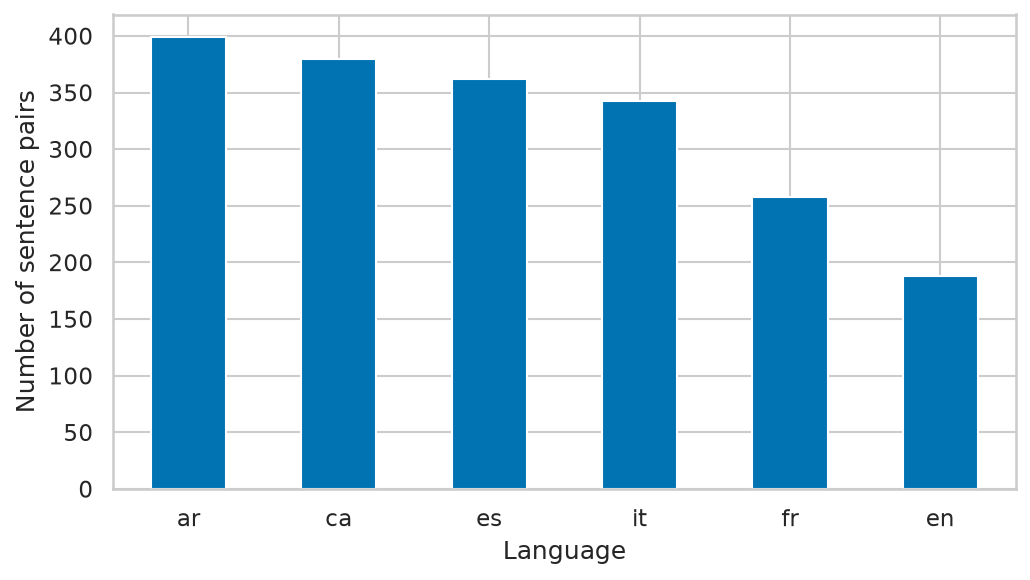

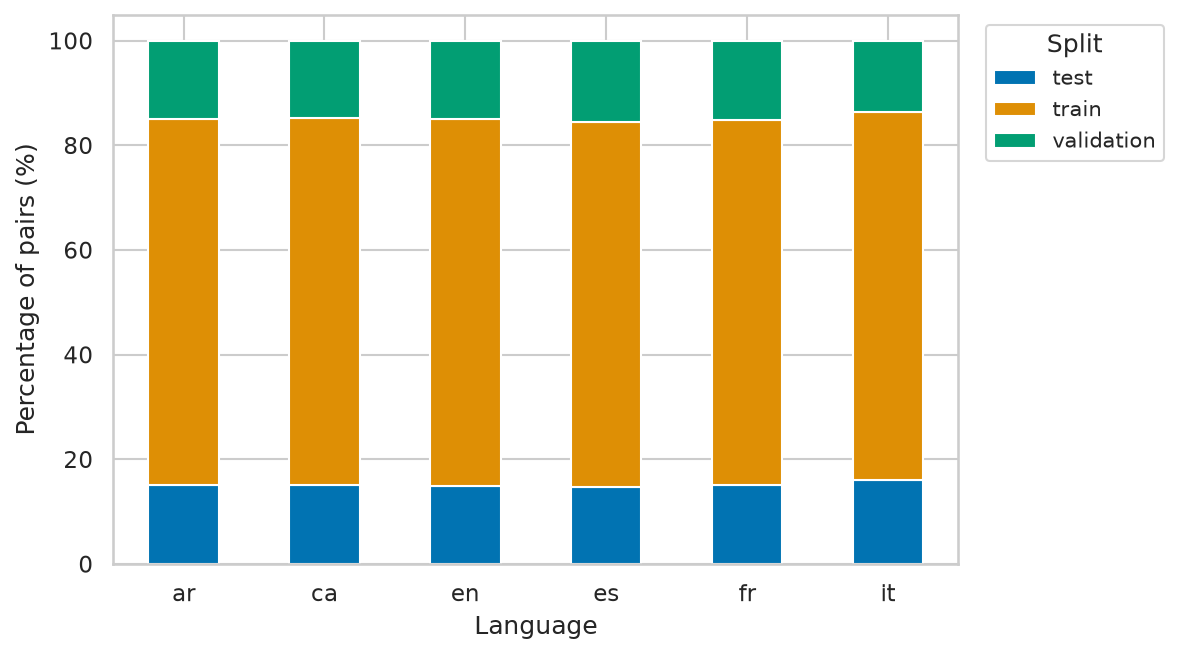

In [4]:
# 3. Dataset composition

# Counts by single dimension
by_language = pairs["language"].value_counts().rename("n_pairs")
by_collection = pairs["collection"].value_counts().rename("n_pairs")
by_split = pairs["split"].value_counts().rename("n_pairs")
by_document = pairs.groupby("language")["document_id"].nunique().rename("n_documents")

table_02 = pd.concat(
    [
        by_language.rename_axis("language").reset_index().assign(dimension="language"),
    ],
    ignore_index=True,
)

# Build a tidy composition table: one row per dimension value, with counts and percentages
composition_rows = []
for dim_name, series in [("language", by_language), ("collection", by_collection), ("split", by_split)]:
    total = series.sum()
    for value, count in series.items():
        composition_rows.append({
            "dimension": dim_name,
            "value": value,
            "n_pairs": count,
            "pct": round(100 * count / total, 2),
        })

table_02 = pd.DataFrame(composition_rows)
table_02.to_csv(TABLES_DIR / "table_02_dataset_composition.csv", index=False)

# Documents per language and collection
docs_by_language = pairs.groupby("language")["document_id"].nunique().rename("n_documents")
docs_by_collection = pairs.groupby("collection")["document_id"].nunique().rename("n_documents")

# Language x split, collection x split cross-tabs
language_split_counts = pd.crosstab(pairs["language"], pairs["split"])
language_split_counts["total"] = language_split_counts.sum(axis=1)
language_split_counts = language_split_counts.join(docs_by_language)
language_split_counts.to_csv(TABLES_DIR / "table_03_language_split_counts.csv")

collection_split_counts = pd.crosstab(pairs["collection"], pairs["split"])
collection_split_counts["total"] = collection_split_counts.sum(axis=1)

print("=== table_02_dataset_composition.csv ===")
print(table_02.to_string(index=False))
print()
print("=== table_03_language_split_counts.csv ===")
print(language_split_counts.to_string())
print()
print("=== collection x split (for reference) ===")
print(collection_split_counts.to_string())

# Figure 1: pairs by language
fig, ax = plt.subplots(figsize=(7, 4))
by_language.sort_values(ascending=False).plot(kind="bar", ax=ax, color=sns.color_palette("colorblind")[0])
ax.set_xlabel("Language")
ax.set_ylabel("Number of sentence pairs")
ax.tick_params(axis="x", rotation=0)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "figure_01_pairs_by_language.pdf")
fig.savefig(FIGURES_DIR / "figure_01_pairs_by_language.png", dpi=300)
plt.show()

# Figure 2: split distribution by language (stacked, with clear denominator)
split_by_lang_pct = pd.crosstab(pairs["language"], pairs["split"], normalize="index") * 100
fig, ax = plt.subplots(figsize=(8, 4.5))
split_by_lang_pct.plot(kind="bar", stacked=True, ax=ax, color=sns.color_palette("colorblind", n_colors=split_by_lang_pct.shape[1]))
ax.set_xlabel("Language")
ax.set_ylabel("Percentage of pairs (%)")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Split", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "figure_02_split_distribution_by_language.pdf")
fig.savefig(FIGURES_DIR / "figure_02_split_distribution_by_language.png", dpi=300)
plt.show()

## Questions to answer

- Which languages and collections are largest and smallest?
- Is Italian dominated by the main Italian collection?
- Is the train/validation/test allocation reasonably consistent across languages?
- Which language-level comparisons may have lower statistical power?

**Intern response:**
* **Largest/smallest**: Arabic is the biggest language (399 pairs, 20.7%), English the smallest (188, 9.7%). At the collection level, it_carlo is tiny (23 pairs, 1.2%); by far the smallest slice of the whole dataset

* **Is Italian dominated by the main collection**? Yes, iDEM Italian provides 320 of Italian's 343 pairs (93%), with Carlo Italian contributing just 23 (7%)

* **Is train/val/test allocation consistent across languages**? Yes, reasonably so. Every language sits close to a 70/15/15 split (e.g. Arabic: 70.0/15.0/15.0, Italian: 70.3/15.9/13.8, English: 70.2/14.9/14.9). No language is wildly off that pattern

* **Which comparisons may have lower statistical power**? Anything involving it_carlo specifically (only 23 pairs total, and just 3–4 pairs in validation/test). Any language or collection-level statistic broken down that finely will be unreliable. English, at 188 pairs, is also comparatively small next to Arabic/Catalan/Spanish

# 4. Sentence-length analysis

## Derived variables

Create at least:

- `length_difference = n_target_tokens - n_source_tokens`
- `tokens_removed = n_source_tokens - n_target_tokens`
- `length_reduction_rate = (n_source_tokens - n_target_tokens) / n_source_tokens`
- categorical direction: `shorter`, `same`, or `longer`

Keep negative reduction values; they represent target expansion.

## Descriptive statistics

Report count, mean, standard deviation, median, Q1, Q3, minimum and maximum for source length, target length, difference, ratio and reduction rate:

- overall;
- by language;
- by collection;
- by split.

### Required outputs

- `table_04_length_summary_overall.csv`
- `table_05_length_summary_by_language.csv`
- `table_06_length_direction_by_language.csv`
- `figure_03_source_target_lengths_by_language.pdf` and `.png`
- `figure_04_length_reduction_distribution.pdf` and `.png`

Use a paired visualisation or grouped box/violin plots for source versus target lengths. Make extreme outliers visible without allowing them to hide the central distribution.

=== table_04: overall length summary ===
  group              variable  count      mean       std  median        q1        q3   min        max
overall       n_source_tokens   1930 25.506736 17.764142    22.0 12.000000 34.000000   1.0 230.000000
overall       n_target_tokens   1930 26.408290 20.770940    21.0 11.000000 35.000000   1.0 214.000000
overall     length_difference   1930  0.901554 12.995339     0.0 -4.000000  4.000000 -67.0  96.000000
overall        tokens_removed   1930 -0.901554 12.995339     0.0 -4.000000  4.000000 -96.0  67.000000
overall length_reduction_rate   1930 -0.165606  2.300733     0.0 -0.213906  0.178571 -96.0   0.859155

=== table_05: length summary by language (source/target tokens only) ===
group        variable  count      mean       std  median   q1   q3  min   max
   ar n_source_tokens    399 21.654135 14.407587    18.0 12.0 28.0  3.0 114.0
   ar n_target_tokens    399 16.421053 10.724890    14.0  9.0 21.0  3.0  76.0
   ca n_source_tokens    380 30.413158 

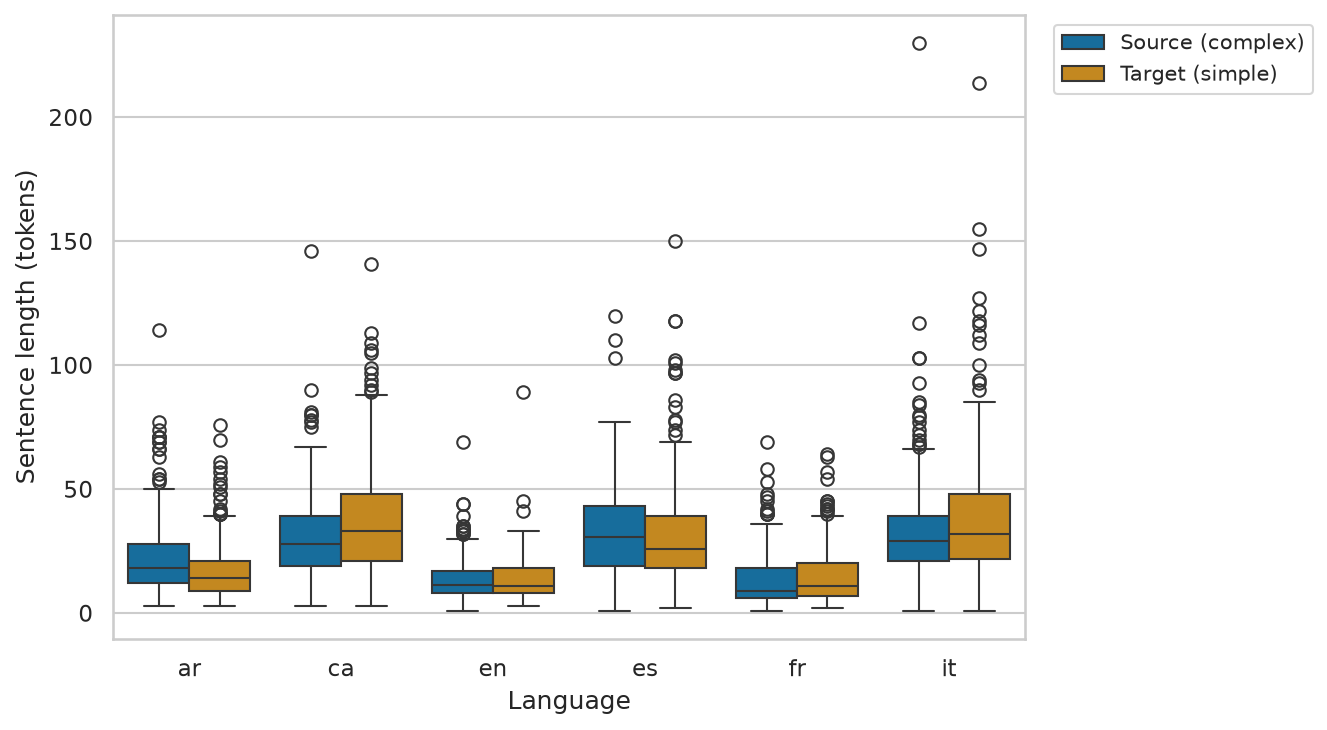

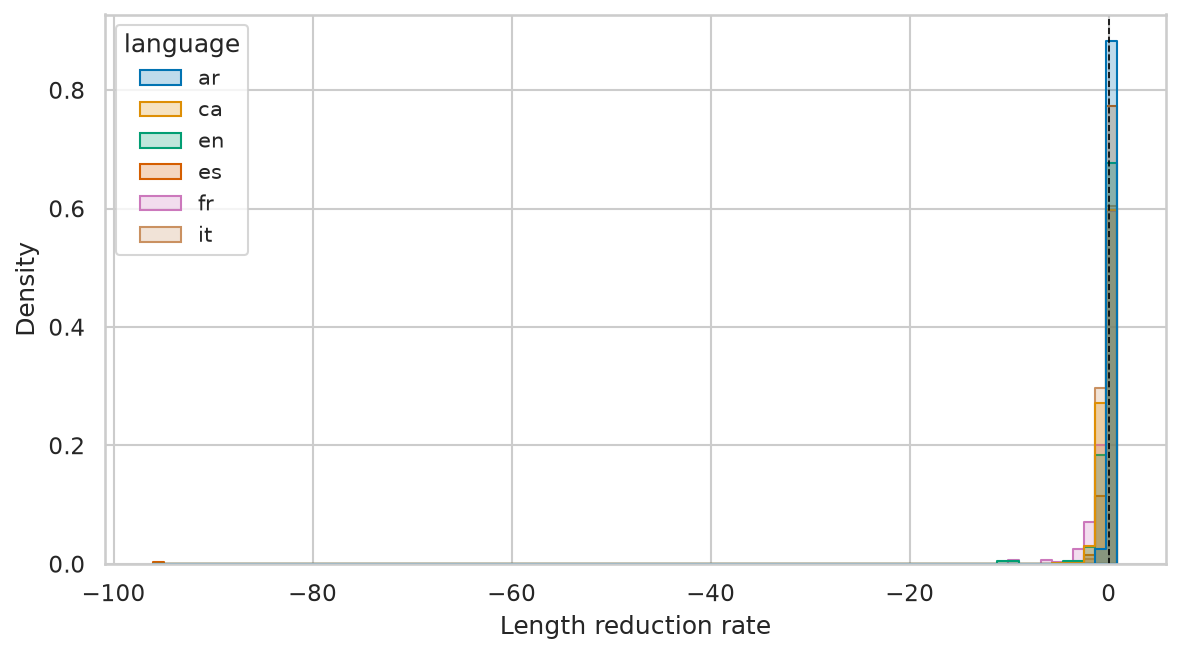

In [5]:
# 4. Sentence-length analysis

# Derived variables
pairs["length_difference"] = pairs["n_target_tokens"] - pairs["n_source_tokens"]
pairs["tokens_removed"] = pairs["n_source_tokens"] - pairs["n_target_tokens"]
pairs["length_reduction_rate"] = (pairs["n_source_tokens"] - pairs["n_target_tokens"]) / pairs["n_source_tokens"]

def direction(row):
    if row["n_target_tokens"] < row["n_source_tokens"]:
        return "shorter"
    elif row["n_target_tokens"] > row["n_source_tokens"]:
        return "longer"
    return "same"

pairs["length_direction"] = pairs.apply(direction, axis=1)

# Descriptive statistics helper
def describe_group(df, value_cols, group_col=None):
    rows = []
    groups = [("overall", df)] if group_col is None else list(df.groupby(group_col))
    for group_value, group_df in groups:
        for col in value_cols:
            s = group_df[col]
            rows.append({
                "group": group_value,
                "variable": col,
                "count": s.count(),
                "mean": s.mean(),
                "std": s.std(),
                "median": s.median(),
                "q1": s.quantile(0.25),
                "q3": s.quantile(0.75),
                "min": s.min(),
                "max": s.max(),
            })
    return pd.DataFrame(rows)

length_vars = [
    "n_source_tokens", "n_target_tokens", "length_difference",
    "tokens_removed", "length_reduction_rate",
]

# table_04: overall
table_04 = describe_group(pairs, length_vars)
table_04.to_csv(TABLES_DIR / "table_04_length_summary_overall.csv", index=False)

# table_05: by language
table_05 = describe_group(pairs, length_vars, group_col="language")
table_05.to_csv(TABLES_DIR / "table_05_length_summary_by_language.csv", index=False)

# Also compute by collection and by split, for completeness
table_05_by_collection = describe_group(pairs, length_vars, group_col="collection")
table_05_by_split = describe_group(pairs, length_vars, group_col="split")

# table_06: length direction by language
table_06 = pd.crosstab(pairs["language"], pairs["length_direction"], normalize="index") * 100
table_06["n_pairs"] = pairs.groupby("language").size()
table_06.to_csv(TABLES_DIR / "table_06_length_direction_by_language.csv")

print("=== table_04: overall length summary ===")
print(table_04.to_string(index=False))
print()
print("=== table_05: length summary by language (source/target tokens only) ===")
print(table_05[table_05["variable"].isin(["n_source_tokens", "n_target_tokens"])].to_string(index=False))
print()
print("=== table_06: length direction by language (%) ===")
print(table_06.to_string())

# Figure 3: paired source vs target lengths by language
plot_df = pairs.melt(
    id_vars=["language"],
    value_vars=["n_source_tokens", "n_target_tokens"],
    var_name="side", value_name="n_tokens"
)
plot_df["side"] = plot_df["side"].map({"n_source_tokens": "Source (complex)", "n_target_tokens": "Target (simple)"})

fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=plot_df, x="language", y="n_tokens", hue="side", ax=ax, palette="colorblind", showfliers=True)
ax.set_xlabel("Language")
ax.set_ylabel("Sentence length (tokens)")
ax.legend(title=None, bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "figure_03_source_target_lengths_by_language.pdf")
fig.savefig(FIGURES_DIR / "figure_03_source_target_lengths_by_language.png", dpi=300)
plt.show()

# Figure 4: length reduction rate distribution
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.histplot(data=pairs, x="length_reduction_rate", hue="language", element="step", stat="density", common_norm=False, ax=ax, palette="colorblind")
ax.set_xlabel("Length reduction rate")
ax.set_ylabel("Density")
ax.axvline(0, color="black", linestyle="--", linewidth=0.8)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "figure_04_length_reduction_distribution.pdf")
fig.savefig(FIGURES_DIR / "figure_04_length_reduction_distribution.png", dpi=300)
plt.show()

## Statistical analysis of length change

After inspecting the distributions:

1. Test whether target token length differs from source token length overall.
2. Repeat the paired comparison within each language.
3. Report an effect size and 95% confidence interval, not only a p-value.
4. Correct the language-level p-values for multiple comparisons using Holm correction.
5. Report the percentage of pairs that became shorter, stayed equal or became longer.

A paired Wilcoxon signed-rank test is suitable when the difference distribution is non-normal. Explain the test choice. Do not rely on a large-sample Shapiro test as the sole decision criterion.

Save the results as `table_07_length_tests.csv`.

In [6]:
# Statistical analysis of length change

from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

def wilcoxon_effect_size(source, target):
    """Paired Wilcoxon signed-rank test with a rank-biserial effect size
    and a bootstrap 95% CI for the median difference."""
    diff = target - source
    diff_nonzero = diff[diff != 0]  # wilcoxon drops zero-differences internally, but we need n for effect size
    n = len(diff_nonzero)

    stat, p = wilcoxon(source, target, zero_method="wilcox")

    # Rank-biserial effect size via normal approximation
    mean_w = n * (n + 1) / 4
    std_w = np.sqrt(n * (n + 1) * (2 * n + 1) / 24)
    z = (stat - mean_w) / std_w
    r = z / np.sqrt(n)

    # Bootstrap 95% CI for the median difference
    rng = np.random.default_rng(RANDOM_SEED)
    boot_medians = [
        np.median(rng.choice(diff, size=len(diff), replace=True))
        for _ in range(2000)
    ]
    ci_low, ci_high = np.percentile(boot_medians, [2.5, 97.5])

    return {
        "n": len(source),
        "n_nonzero_diff": n,
        "median_diff": np.median(diff),
        "ci_low": ci_low,
        "ci_high": ci_high,
        "wilcoxon_stat": stat,
        "p_value": p,
        "effect_size_r": r,
    }

length_test_rows = []

# Overall test
overall_result = wilcoxon_effect_size(pairs["n_source_tokens"].values, pairs["n_target_tokens"].values)
overall_result["group"] = "overall"
length_test_rows.append(overall_result)

# Per-language tests
for lang, group in pairs.groupby("language"):
    result = wilcoxon_effect_size(group["n_source_tokens"].values, group["n_target_tokens"].values)
    result["group"] = lang
    length_test_rows.append(result)

table_07 = pd.DataFrame(length_test_rows)
table_07 = table_07[["group", "n", "n_nonzero_diff", "median_diff", "ci_low", "ci_high", "wilcoxon_stat", "p_value", "effect_size_r"]]

# Holm correction applied only across the per-language tests (the overall test is a separate question)
language_mask = table_07["group"] != "overall"
_, p_corrected, _, _ = multipletests(table_07.loc[language_mask, "p_value"], method="holm")
table_07["p_value_holm"] = table_07["p_value"]
table_07.loc[language_mask, "p_value_holm"] = p_corrected

table_07.to_csv(TABLES_DIR / "table_07_length_tests.csv", index=False)

print(table_07.to_string(index=False))
print()
print("Length direction, all pairs:")
print(pairs["length_direction"].value_counts(normalize=True).mul(100).round(2))

  group    n  n_nonzero_diff  median_diff  ci_low  ci_high  wilcoxon_stat      p_value  effect_size_r  p_value_holm
overall 1930            1658          0.0     0.0      0.0       683321.0 8.239023e-01      -0.005460  8.239023e-01
     ar  399             332         -3.0    -3.0     -2.0         3721.5 1.152361e-42      -0.749981  6.914167e-42
     ca  380             345          2.0     1.0      3.0        15397.5 6.351369e-15      -0.419495  3.175684e-14
     en  188             149          0.0     0.0      0.0         5331.5 6.268939e-01      -0.039745  6.268939e-01
     es  362             325         -2.0    -2.5     -1.0        18628.0 3.490922e-06      -0.257169  1.047277e-05
     fr  258             186          0.0     0.0      1.0         6172.0 5.892392e-04      -0.251664  1.178478e-03
     it  343             321          2.0     1.0      3.0        14088.5 1.577120e-12      -0.394166  6.308481e-12

Length direction, all pairs:
length_direction
shorter    46.01
longer  

## Interpretation

Explain the magnitude of change, not merely whether it is statistically significant. Identify languages with expansion as well as reduction. Do not equate shortening with simplification quality.

**Intern response:**
* **Overall** (**pooled across all languages**): no significant length change (p=0.82, effect size ≈ 0). But that's misleading in isolation, it's not that nothing's happening, it's that opposite effects in different languages cancel each other out.

* **Arabic shortens strongly and significantly**: Median -3 tokens, by far the largest effect size (r = -0.75). This matches the 74.7% "shorter" figure from earlier

* **Spanish also shortens significantly**, though more modestly (median -2, r = -0.26)

* **Catalan and Italian expand significantly**: Median +2 tokens each (r = -0.42 and -0.39), consistent with the 58-59% "longer" figures from table_06

* **French is significant despite a median difference of 0**: Worth flagging as a subtlety: the test detects an asymmetric shift in the distribution (via ranks) even though the median sits exactly at zero, so French's simplifications aren't uniformly longer or shorter; they're more varied/mixed in direction

* **English shows no significant change** (p=0.63): Simplification there doesn't reliably make sentences longer or shorter, just different

# 5. Alignment analysis

## Task

Analyse:

- `n_alignment_links`;
- `source_alignment_coverage`;
- `target_alignment_coverage`;
- links per source token;
- links per target token;
- number and percentage of pairs below sensible coverage thresholds such as 0.50, 0.70 and 0.90.

Report the results overall and by language and collection.

### Required outputs

- `table_08_alignment_summary.csv`
- `table_09_low_coverage_pairs.csv`
- `figure_05_alignment_coverage_by_language.pdf` and `.png`
- `figure_06_source_vs_target_coverage.pdf` and `.png`

For the second figure, use a scatter plot with a diagonal reference line. Consider transparency because points overlap.

=== table_08: alignment summary (coverage variables only) ===
   group                  variable  count      mean       std  median      q1       q3   min   max  dimension
 overall source_alignment_coverage   1930 77.897503 17.753896  79.170 66.6700  92.5475 10.53 100.0    overall
 overall target_alignment_coverage   1930 78.662523 20.173464  81.820 63.6400 100.0000  3.09 100.0    overall
      ar source_alignment_coverage    399 79.218647 19.507496  83.330 67.2050  96.0750 20.00 100.0   language
      ar target_alignment_coverage    399 96.712431  8.213312 100.000 97.5900 100.0000 38.10 100.0   language
      ca source_alignment_coverage    380 78.325184 13.227178  78.260 68.4200  87.1000 40.62 100.0   language
      ca target_alignment_coverage    380 69.327868 17.714895  69.635 57.0450  81.8200 15.22 100.0   language
      en source_alignment_coverage    188 80.498404 22.529892  88.195 66.3475 100.0000 10.53 100.0   language
      en target_alignment_coverage    188 81.519043 21.225

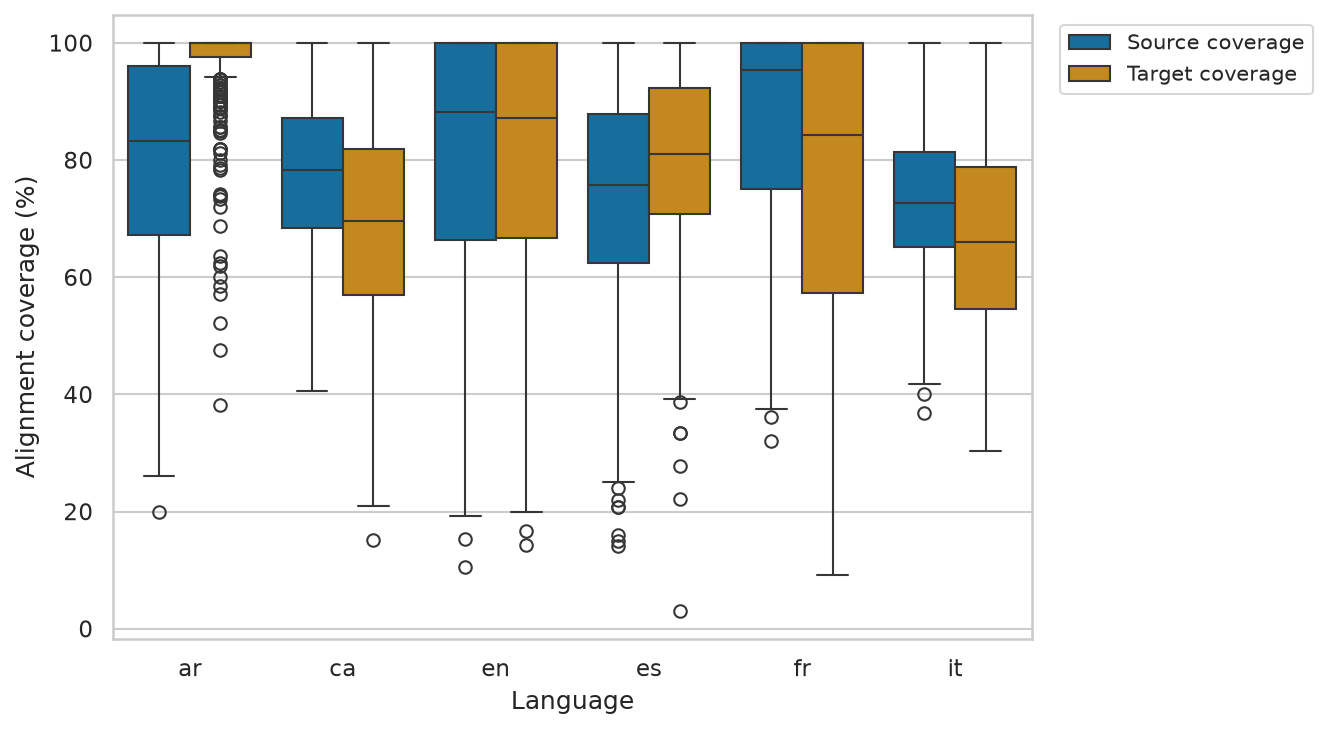

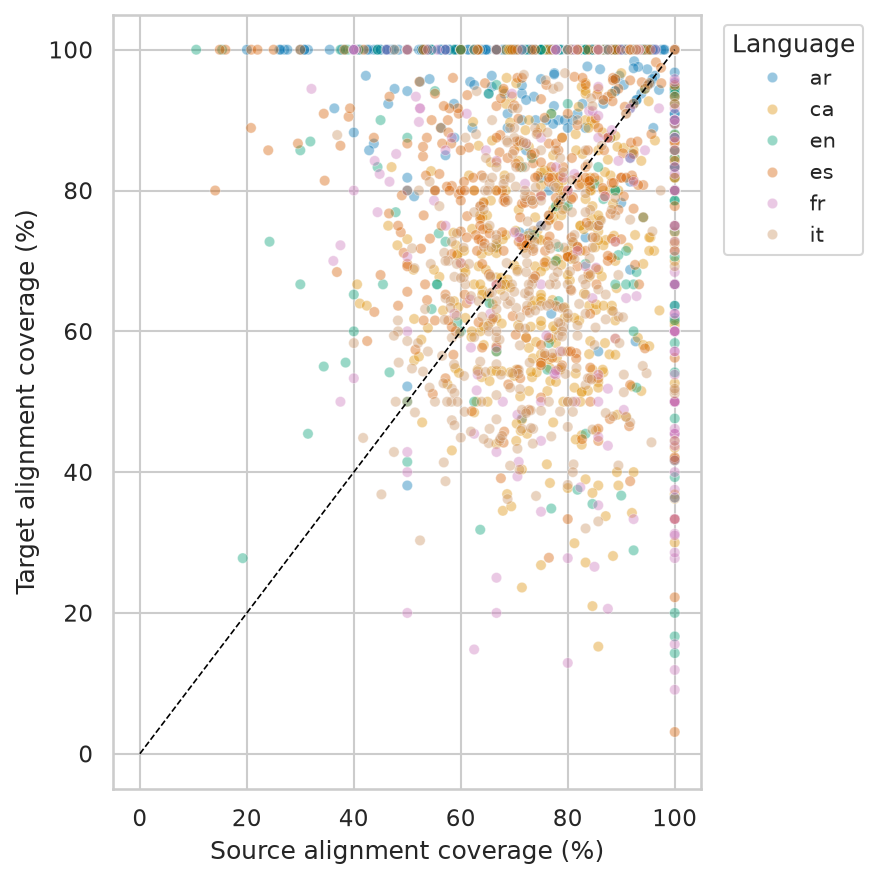

In [7]:
# 5. Alignment analysis

# Derived variables
pairs["links_per_source_token"] = pairs["n_alignment_links"] / pairs["n_source_tokens"]
pairs["links_per_target_token"] = pairs["n_alignment_links"] / pairs["n_target_tokens"]

alignment_vars = [
    "n_alignment_links", "source_alignment_coverage", "target_alignment_coverage",
    "links_per_source_token", "links_per_target_token",
]

# table_08: alignment summary, overall + by language + by collection
table_08_overall = describe_group(pairs, alignment_vars).assign(dimension="overall")
table_08_language = describe_group(pairs, alignment_vars, group_col="language").assign(dimension="language")
table_08_collection = describe_group(pairs, alignment_vars, group_col="collection").assign(dimension="collection")

table_08 = pd.concat([table_08_overall, table_08_language, table_08_collection], ignore_index=True)
table_08.to_csv(TABLES_DIR / "table_08_alignment_summary.csv", index=False)

print("=== table_08: alignment summary (coverage variables only) ===")
print(table_08[table_08["variable"].isin(["source_alignment_coverage", "target_alignment_coverage"])].to_string(index=False))

# table_09: pairs below coverage thresholds
# NOTE: coverage columns are stored as percentages (0-100), so thresholds are 50/70/90
thresholds = [50, 70, 90]
low_coverage_rows = []

for threshold in thresholds:
    for side, col in [("source", "source_alignment_coverage"), ("target", "target_alignment_coverage")]:
        below = pairs[pairs[col] < threshold]
        low_coverage_rows.append({
            "threshold": threshold,
            "side": side,
            "n_pairs_below": len(below),
            "pct_pairs_below": round(100 * len(below) / len(pairs), 2),
        })

table_09_summary = pd.DataFrame(low_coverage_rows)

# Also save the actual low-coverage pairs (using the strictest threshold, 90) for inspection
table_09_pairs = pairs[
    (pairs["source_alignment_coverage"] < 90) | (pairs["target_alignment_coverage"] < 90)
][["pair_id", "language", "collection", "source_alignment_coverage", "target_alignment_coverage"]]

table_09_summary.to_csv(TABLES_DIR / "table_09_low_coverage_pairs.csv", index=False)

print()
print("=== table_09: pairs below coverage thresholds ===")
print(table_09_summary.to_string(index=False))
print()
print(f"Total pairs below 90% coverage (either side): {len(table_09_pairs)} ({100*len(table_09_pairs)/len(pairs):.2f}%)")

# Figure 5: alignment coverage by language
plot_df = pairs.melt(
    id_vars=["language"],
    value_vars=["source_alignment_coverage", "target_alignment_coverage"],
    var_name="side", value_name="coverage"
)
plot_df["side"] = plot_df["side"].map({
    "source_alignment_coverage": "Source coverage",
    "target_alignment_coverage": "Target coverage",
})

fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=plot_df, x="language", y="coverage", hue="side", ax=ax, palette="colorblind")
ax.set_xlabel("Language")
ax.set_ylabel("Alignment coverage (%)")
ax.legend(title=None, bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "figure_05_alignment_coverage_by_language.pdf")
fig.savefig(FIGURES_DIR / "figure_05_alignment_coverage_by_language.png", dpi=300)
plt.show()

# Figure 6: source vs target coverage scatter, with diagonal reference line
fig, ax = plt.subplots(figsize=(6, 6))
sns.scatterplot(
    data=pairs, x="source_alignment_coverage", y="target_alignment_coverage",
    hue="language", alpha=0.4, s=25, ax=ax, palette="colorblind",
)
ax.plot([0, 100], [0, 100], color="black", linestyle="--", linewidth=0.8)
ax.set_xlabel("Source alignment coverage (%)")
ax.set_ylabel("Target alignment coverage (%)")
ax.legend(title="Language", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "figure_06_source_vs_target_coverage.pdf")
fig.savefig(FIGURES_DIR / "figure_06_source_vs_target_coverage.png", dpi=300)
plt.show()

## Alignment questions

- Which language has the lowest typical source or target coverage?
- Are low-coverage observations rare outliers or a systematic subgroup?
- Is low coverage related to source length?
- Could low alignment coverage cause genuine edits to be labelled incorrectly?
- Propose one coverage threshold for a later sensitivity analysis, but do not remove any pair yet.

**Intern response:**
* **Lowest coverage**: Italian has the lowest alignment coverage on both source (73.2%) and target (67.4%) sides. Noticeably weaker than every other language

* **Rare outliers or systematic**?  it's systematic, and lines up with what I found in Section 4: Italian (along with Catalan) tends to expand during simplification rather than shorten, so more of the target sentence ends up as new, unaligned content

* **Related to source length**? Checked directly whether coverage relates to source length using Spearman correlation: source coverage vs source length gives rho=-0.522, target coverage vs source length gives rho=-0.271. Both moderate negative correlations, so longer source sentences do tend to have worse alignment coverage

* **Could low coverage mislabel genuine edits**? Yes: A token that's technically alignable but the alignment algorithm missed will look identical in the data to a genuine DELETE/INSERT, which could inflate apparent edit rates for low-coverage languages like Italian

* **Propose a threshold for later sensitivity analysis**: Given the numbers, 70% seems like a reasonable candidate. Strict enough to exclude clearly poor alignments, without excluding the majority of the dataset like 90% would.

# 6. Human-edit operation analysis

## Preparation

Merge the pair-level split information into `source_tokens.csv`.

Validate that, within every pair:

- the number of token rows equals `n_source_tokens`;
- operation counts sum to the source-token count;
- binary masks contain only 0 and 1;
- `content_edit` is not marked for punctuation excluded by `is_content`.

## Descriptive analysis

Create:

- operation counts and percentages overall;
- operation counts and percentages by language;
- operation counts and percentages by collection;
- pair-level counts of each operation;
- pair-level lexical, full and content edit rates;
- prevalence of any reordering.

### Required outputs

- `table_10_operation_counts_overall.csv`
- `table_11_operation_profile_by_language.csv`
- `table_12_pair_edit_rate_summary.csv`
- `figure_07_operation_profile_by_language.pdf` and `.png`
- `figure_08_content_edit_rate_by_language.pdf` and `.png`
- `figure_09_operation_support.pdf` and `.png`

A normalised stacked bar chart or heatmap is suitable for operation profiles. Also show absolute support somewhere, because percentages alone can hide small samples.

## Operation-profile statistics

At the **sentence-pair level**, investigate whether edit behaviour differs by language.

Required analyses:

1. Compare pair-level content edit rates across languages using a suitable omnibus test.
2. If significant, conduct corrected post-hoc comparisons.
3. Test whether the categorical operation profile is associated with language.
4. Report effect sizes:
   - epsilon-squared or another justified effect size for the omnibus rank test;
   - Cramér's V for the operation × language contingency table.
5. Clearly distinguish descriptive token counts from pair-level inference.

Save as:

- `table_13_edit_rate_tests.csv`
- `table_14_operation_language_association.csv`

## Interpretation

- Which operations dominate overall?
- Which operations have low support and may produce unstable attribution estimates?
- Which languages show unusually high DELETE, SUBSTITUTE, MERGE, SPLIT or COMPLEX rates?
- Are differences likely to reflect actual simplification practice, alignment behaviour, collection composition, or a combination?

**Intern response:**

# 7. Relationships among variables

## Task

At the sentence-pair level, calculate and visualise relationships among:

- source length;
- target length;
- length reduction rate;
- source content edit rate;
- source and target alignment coverage;
- number of alignment links;
- counts of DELETE, SUBSTITUTE, MERGE, SPLIT and COMPLEX operations.

Use Spearman correlations unless a different choice is justified.

### Required outputs

- `table_15_spearman_correlations.csv`
- `figure_10_reduction_vs_edit_rate.pdf` and `.png`
- `figure_11_length_vs_number_of_edits.pdf` and `.png`
- `figure_12_pair_level_correlation_matrix.pdf` and `.png`

For scatter plots, show language using facets or clearly distinguishable groups. Avoid fitting a single regression line that hides language-level structure.

## Questions

- Does greater shortening correspond to a higher content edit rate?
- Do longer sentences contain more edits simply because they contain more tokens?
- Does low alignment coverage systematically raise or lower the measured edit rate?
- Which variables may confound later attribution evaluation?

**Intern response:**

# 8. Train, validation and test comparability

## Task

Compare splits on:

- language and collection composition;
- source and target lengths;
- length reduction rate;
- source content edit rate;
- source and target alignment coverage;
- operation profile.

Produce:

- `table_16_split_comparison.csv`
- `figure_13_split_feature_comparison.pdf` and `.png`

The goal is not to force identical distributions. The goal is to identify differences that must be considered when interpreting classifier and attribution results.

## Split conclusion

State:

- whether the test set is broadly representative;
- which variables differ most;
- whether later XAI metrics should be macro-averaged by language as well as micro-averaged across all pairs.

**Intern response:**

# Part II. In-Depth Linguistic Edit and Strategy Analysis

These linguistic and strategy-readiness analyses form the second part of the same Stage 1 data-understanding task.

## Conceptual distinction

Alignment-derived operations and human simplification strategies are related, but they are **not interchangeable**.

Examples:

- an unaligned source token is evidence of a local `DELETE` operation, but it does not by itself prove that the whole sentence uses the macro-strategy **Omission**;
- an unaligned target token is an `INSERT`, but it may realise **Explanation**, grammatical repair, discourse marking or another strategy;
- `SUBSTITUTE` is a structural alignment operation, whereas the annotated strategy **Substitution** is a linguistic interpretation;
- `MERGE`, `SPLIT` and reordering may support **Compression**, **Syntactic Changes** or **Transposition**, but context is required;
- **Modulation** and **Transcription** cannot be identified reliably from alignment topology alone.

Every result must preserve this distinction.

# 9. Exact complex-versus-simple quartile and IQR analysis

## Mandatory table

For each language and each side separately:

- complex/original;
- simple/simplified;

report the following for sentence token count:

- number of sentences;
- mean;
- standard deviation;
- minimum;
- Q1;
- median;
- Q3;
- IQR (`Q3 - Q1`);
- maximum;
- 95% bootstrap confidence interval for the median.

Produce one row per `language × side`.

Save:

- `table_17_token_length_iqr_by_language_and_side.csv`
- `table_17_token_length_iqr_by_language_and_side.tex`

The labels in the output must be `Complex` and `Simple`, not only `source` and `target`.

## Additional paired quartile analysis

For each language, also report Q1, median, Q3 and IQR for:

- paired token difference: `simple_tokens - complex_tokens`;
- proportional reduction;
- character-count difference;
- content-word-count difference, after linguistic annotation is available.

Produce:

- `table_18_paired_change_iqr_by_language.csv`
- `figure_14_complex_simple_length_by_language.pdf` and `.png`
- `figure_15_paired_length_change_by_language.pdf` and `.png`

The first figure should make complex and simple distributions directly comparable within each language. The second should show the distribution of paired change, including expansion below zero where relevant.

## Required interpretation

For every language, answer:

- What is the median complex sentence length?
- What is the median simple sentence length?
- What are the two IQRs?
- Is the simple distribution merely shifted downward, or is it also narrower or wider?
- Does the language contain a substantial group of expanded simplifications?
- Could different language-specific tokenisation practices affect direct comparison?

Do not compare raw token counts across languages without discussing tokenisation.

**Intern response:**

# 10. Build a two-sided token and edit table

The existing `source_tokens.csv` contains source-side operations. The pair file also contains `target_tokens` and `target_operations`.

## Task

Create a long-format token table with one row per token and the following fields:

- `pair_id`;
- language, collection, document and split;
- `side`: `complex` or `simple`;
- token index and surface form;
- operation;
- degree;
- aligned token indices;
- normalised token position from 0 to 1;
- punctuation/content/function status when available;
- linguistic annotations added later.

Validate:

- source-side operation counts against `source_tokens.csv`;
- target-side `INSERT` counts;
- token counts against the pair table;
- operation values against the allowed vocabulary.

Save:

- `derived_edit_tokens_long.csv`
- `table_19_two_sided_operation_counts.csv`

# 11. Deletion and addition span analysis

A deletion is a contiguous sequence of source tokens labelled `DELETE`. An addition is a contiguous sequence of target tokens labelled `INSERT`.

## Task 11A: Identify edit spans

Within each pair and side:

1. sort tokens by index;
2. group consecutive `DELETE` or `INSERT` tokens into spans;
3. retain the span text, length, start and end indices;
4. calculate normalised span location:
   - beginning: midpoint < 0.33;
   - middle: 0.33–0.66;
   - end: > 0.66;
5. record whether the span is one token or multiple tokens.

Produce:

- `derived_deletion_addition_spans.csv`
- `table_20_span_length_and_location.csv`
- `figure_16_deletion_addition_span_lengths.pdf` and `.png`
- `figure_17_edit_location_by_language.pdf` and `.png`

## Task 11B: Questions

Answer overall and by language:

- How many deletion and addition spans occur?
- What are their median, Q1, Q3 and IQR lengths?
- What percentage are single-token versus multi-token spans?
- Are deletions or additions concentrated at sentence beginnings, middles or ends?
- Are some languages characterised by many small edits and others by fewer long spans?
- How many pairs contain both deletion and addition?

**Intern response:**

# 12. Linguistic annotation with spaCy and UDPipe dependencies

Use **spaCy with `spacy-udpipe`** as the common multilingual annotation framework.

UDPipe supplies:

- sentence and word tokenisation when raw text is used;
- Universal POS tags;
- language-specific XPOS tags;
- lemmas;
- Universal Dependencies morphological features;
- dependency heads and dependency relations.

The output is exposed through spaCy `Doc` and `Token` objects.

## Required languages and codes

| Dataset language | UDPipe/spaCy code |
|---|---|
| Arabic | `ar` |
| Catalan | `ca` |
| English | `en` |
| Spanish | `es` |
| French | `fr` |
| Italian | `it` |

## Primary tokenisation policy

Use the existing alignment tokens as **pretokenised UDPipe input**. This is essential because DELETE, INSERT, SUBSTITUTE, SPLIT, MERGE and COMPLEX operations already refer to those exact token indices.

For one sentence with token list `tokens`, pass a one-sentence pretokenised structure:

```python
doc = nlp([tokens])
```

The returned token sequence must exactly equal the input sequence. Treat any mismatch as an error and record it.

Do not run raw-text UDPipe tokenisation and then assume that the resulting tokens correspond to the alignment tokens.

## Required token annotations

Retain:

- `token.text`;
- `token.i`;
- `token.lemma_`;
- `token.pos_` as UPOS;
- `token.tag_` as language-specific XPOS;
- `str(token.morph)`;
- `token.dep_`;
- `token.head.i`;
- whether the token is the root;
- the token's number of children;
- sentence-pair metadata, side and edit operation.

## Named entities

`spacy-udpipe` provides UD morphology and dependency parsing, but it does not provide a common multilingual named-entity recogniser.

For the primary six-language comparison:

- use `PROPN` and documented dependency patterns as the common proper-name signal;
- do not make the main deletion/addition taxonomy depend on NER;
- optionally run separate spaCy NER pipelines for languages where a compatible model exists;
- store optional NER output in supplementary columns;
- report Arabic separately because spaCy does not provide an equivalent official Arabic core pipeline;
- never interpret a blank NER field as evidence that a token is not an entity.

This preserves comparability across all six languages.

## Colab installation hint

Add the following commands in your own code cell:

```python
%pip install -q "spacy>=3.7,<4" "spacy-udpipe==1.0.0" "ufal.udpipe>=1.2.0"
```

Load `ar`, `ca`, `en`, `es`, `fr` and `it`, and pass the existing
alignment-token lists as pretokenised input. Verify that UDPipe returns
exactly the same token sequence.


## Intern implementation task

Implement the following:

1. parse `source_tokens` and `target_tokens`;
2. annotate both sides using the pipeline matching `language`;
3. retain the original token index and edit operation;
4. write one row per token;
5. calculate and report annotation completeness by language;
6. fail loudly on token-sequence mismatch;
7. cache the result so later notebook sections do not rerun all models.

Save:

- `derived_spacy_udpipe_tokens.csv`
- `table_21_spacy_udpipe_annotation_quality.csv`
- `spacy_udpipe_model_manifest.json`

The model manifest must include:

- package versions;
- dataset language code;
- downloaded model identifier or path;
- execution date;
- number of annotated sentences and tokens;
- number of failures.

# 13. Linguistic types of deleted and added material

## Operational taxonomy

Assign each deleted or inserted token/span to transparent, reproducible categories. Use the following hierarchy, documenting every rule:

1. **Punctuation**
2. **Number/date**
3. **Named entity or proper name**
4. **Negation**
5. **Discourse marker or connective**
6. **Predicate**: mainly verbal or auxiliary material
7. **Core participant/argument**: subject, object or indirect object
8. **Other nominal information**: noun, proper noun or oblique nominal
9. **Modifier/detail**: adjectival, adverbial, nominal or clausal modifier
10. **Function/grammatical material**: determiner, adposition, conjunction, particle, pronoun or other function item
11. **Mixed span**
12. **Other/unknown**

The category must be based on UDPipe UPOS, XPOS, dependency relation, morphology, lemmas, the common `PROPN` signal and documented lexical lists. Optional spaCy NER may be retained only as supplementary evidence. Because some categories overlap, define a fixed precedence order and retain the raw linguistic fields for later checking.

## Required analyses

For deletions and additions separately, report:

- token counts and percentages by linguistic type;
- span counts and percentages by linguistic type;
- language-specific profiles;
- median and IQR span length for every sufficiently supported type;
- representative examples sampled with a fixed random seed.

Save:

- `table_22_deleted_material_types.csv`
- `table_23_added_material_types.csv`
- `table_24_edit_type_span_statistics.csv`
- `examples_deletion_addition_types.csv`
- `figure_18_deleted_types_by_language.pdf` and `.png`
- `figure_19_added_types_by_language.pdf` and `.png`

## Detailed deletion questions

Investigate whether simplification deletes:

- modifiers and descriptive detail;
- discourse markers;
- function words;
- subjects, objects or other arguments;
- predicates or subordinate clauses;
- named entities, numbers or dates;
- negation.

Flag potentially meaning-changing deletions, especially deletion of negation, predicates, core arguments, named entities and quantities. This is a descriptive warning, not an automatic quality judgement.

**Intern response:**

## Detailed addition questions

Investigate whether simplification adds:

- explanatory nominal material;
- discourse connectives;
- explicit subjects or arguments;
- punctuation or sentence-boundary material;
- function words needed after restructuring;
- names, numbers or examples;
- negation.

Separate substantive additions from punctuation-only additions. Identify whether inserted spans tend to be short grammatical repairs or longer possible explanations.

**Intern response:**

# 14. Broader linguistic complexity profile: complex versus simple

Calculate language-internal paired features using the same annotation system.

## Mandatory universal features

- token count;
- character count;
- mean token length;
- content-token count and lexical density;
- number of unique lemmas and a length-aware lexical-diversity measure;
- verb count;
- finite-verb count where morphology permits;
- estimated clause count;
- subordinate-clause count and rate;
- dependency-tree depth;
- mean and maximum dependency distance;
- punctuation count;
- named-entity count;
- number count;
- negation count.

Use caution with cross-language comparability and document all heuristics.

## Outputs

For every language and side, report median, Q1, Q3 and IQR for every feature.

Save:

- `table_25_linguistic_features_iqr_by_language_and_side.csv`
- `table_26_paired_linguistic_change_by_language.csv`
- `figure_20_linguistic_change_effect_sizes.pdf` and `.png`

Use paired tests, effect sizes, confidence intervals and Holm correction. The effect-size figure should show direction and uncertainty, not only p-values.

# 15. Strategy annotation import and validation

The current processed alignment files do not contain strategy labels. Use either the supplied project annotations or complete `strategy_annotations_template.csv`.

## Required macro-strategy columns

- `Omission`
- `Compression`
- `Explanation`
- `Syntactic_Changes`
- `Substitution`
- `Transposition`
- `Modulation`
- `Transcription`

Values must be binary: 1 = present, 0 = absent. Retain an `annotation_status`, `annotator_id` and `notes` field where available.

## Validation

Check:

- unique `pair_id`;
- coverage of pair IDs in both files;
- binary values only;
- missing or unresolved labels;
- annotation coverage by language and collection;
- label cardinality per pair;
- pairs with no strategy label;
- pairs with multiple strategy labels;
- inter-annotator agreement when more than one annotation is available.

Do not interpret blank cells as zero unless the annotation protocol explicitly says that blanks mean absence.

Save:

- `table_27_strategy_annotation_coverage.csv`
- `table_28_strategy_annotation_quality.csv`

# 16. Simplification-strategy statistics

## Frequency and distribution

Report:

- support and prevalence of each strategy overall;
- support and prevalence by language and collection;
- median, Q1, Q3 and IQR number of strategies per pair;
- percentage of single-label and multi-label pairs;
- most frequent exact strategy combinations;
- label cardinality and label density.

## Co-occurrence

Calculate:

- pairwise co-occurrence counts;
- Jaccard similarity;
- phi coefficient or another justified binary association;
- corrected significance tests where inferential results are shown.

Produce:

- `table_29_strategy_frequency.csv`
- `table_30_strategy_frequency_by_language.csv`
- `table_31_strategy_combinations.csv`
- `table_32_strategy_cooccurrence.csv`
- `figure_21_strategy_support.pdf` and `.png`
- `figure_22_strategy_cooccurrence.pdf` and `.png`
- `figure_23_strategy_combinations_upset.pdf` and `.png`

Use an UpSet plot rather than a Venn diagram for eight multi-label strategies.

## Strategy-distribution questions

- Which strategies are dominant or rare?
- Do label distributions differ substantially by language or collection?
- Which strategies usually appear together?
- Are any language-level strategy results too sparse for reliable inference?
- Does one collection dominate a strategy and therefore confound a language comparison?

**Intern response:**

# 17. Link observed edit signatures to annotated strategies

## Pair-level edit-signature features

Construct one row per sentence pair containing:

- deletion token rate and deletion span count;
- insertion token rate and insertion span count;
- substitution rate;
- split, merge and complex-operation rates;
- reordering rate;
- content edit rate;
- length reduction rate;
- mean and maximum deletion span length;
- mean and maximum insertion span length;
- proportions of linguistic deletion/addition types;
- source length, alignment coverage, language, collection and document.

## Descriptive strategy profiles

For every strategy, compare strategy-present versus strategy-absent pairs. Report:

- N;
- mean and standard deviation;
- median, Q1, Q3 and IQR;
- difference in medians with bootstrap confidence interval;
- suitable effect size.

Save:

- `table_33_edit_signature_by_strategy.csv`
- `figure_24_edit_signature_strategy_heatmap.pdf` and `.png`

## Hypothesis-led associations

Evaluate the following as hypotheses, not assumed truths:

| Strategy | Expected alignment/edit evidence |
|---|---|
| Omission | More deleted content and deletion spans |
| Compression | Length reduction, deletion, merge and denser rewriting |
| Explanation | More substantive insertions and longer insertion spans |
| Syntactic Changes | Split, merge, reordering and syntactic-feature changes |
| Substitution | More one-to-one substitutions |
| Transposition | More reordering/crossing-link evidence |
| Modulation | May involve substitution or complex rewrites, but alignment alone is insufficient |
| Transcription | Surface-form substitution, especially names or representations, but requires linguistic inspection |

For each strategy:

1. test each pre-specified association;
2. correct for multiple comparisons;
3. report effect sizes and uncertainty;
4. inspect whether the effect remains after controlling for source length, language and collection;
5. explicitly report unsupported hypotheses.

Save:

- `table_34_strategy_edit_association_tests.csv`

## Multivariable analysis

Fit an interpretable binary model for each sufficiently supported strategy:

`strategy_present ~ edit_signature_features + source_length + alignment_coverage + language + collection`

Use regularised logistic regression or a justified generalised linear model. Prevent leakage and unstable estimates:

- standardise continuous predictors;
- check collinearity;
- use grouped or stratified cross-validation;
- avoid fitting a model when positive support is too small;
- report cross-validated AUROC and average precision;
- report coefficients or odds ratios with uncertainty;
- perform sensitivity analysis excluding low-alignment-coverage pairs.

This analysis asks whether a strategy has a distinctive observable edit signature. It does **not** replace human strategy annotation.

Save:

- `table_35_strategy_edit_models.csv`
- `figure_25_strategy_model_coefficients.pdf` and `.png`

# 18. Edit-operation and strategy interaction profiles

Go beyond one operation at a time.

## Task

Define transparent pair-level edit profiles such as:

- deletion-dominant;
- insertion-dominant;
- substitution-dominant;
- structural: split/merge/reordering;
- mixed/high-density;
- low-edit/near-copy.

Use documented thresholds based on the data distribution, or use an interpretable clustering method followed by manual validation.

Analyse:

- profile frequency by language;
- strategy prevalence within each profile;
- profile purity and entropy;
- examples nearest each profile centre.

Produce:

- `table_36_edit_profiles.csv`
- `table_37_strategy_by_edit_profile.csv`
- `figure_26_edit_profiles_by_language.pdf` and `.png`

# 19. Methodological robustness and XAI stratification

These checks are part of Stage 1 because they determine whether the
later explainability results can be interpreted fairly.

## A. Stratification variables

Create quartile or principled bands for:

- source length;
- content edit rate;
- source and target alignment coverage;
- deletion rate;
- insertion rate;
- number of annotated strategies, when available.

Save the boundaries and support in
`table_38_xai_stratification_bands.csv`.

## B. Document-aware uncertainty

Sentence pairs from the same document are not fully independent.
Where a language contains multiple documents, calculate cluster-bootstrap
confidence intervals by resampling documents and then retaining their
sentence pairs.

Where a language contains only one document, do not present a
document-cluster interval. Report the limitation explicitly.

## C. Adjusted language comparisons

Use a robust regression or another justified pair-level model to test
whether language differences in length reduction or edit rate remain
after accounting for:

- source sentence length;
- alignment coverage;
- collection, where estimable.

Do not interpret these models causally.

## D. Joint edit-profile comparison

Compare the complete pair-level operation vector across languages using
a multivariate permutation procedure or another justified robust method.
This complements, rather than replaces, operation-by-operation summaries.

## E. Alignment sensitivity

Repeat the main descriptive and association results using at least one
pre-declared high-coverage condition, for example source and target
coverage of at least 0.70. Compare the direction and magnitude of the
results with the full dataset.

## F. Reporting thresholds and examples

Establish minimum support for operation-specific and strategy-specific
reporting. Select reproducible examples of:

- common edit patterns;
- rare operations;
- expected edit–strategy relationships;
- counter-examples;
- low-coverage cases.

Save:

- `table_39_support_and_reporting_thresholds.csv`
- `examples_edit_strategy_cases.csv`

# 20. Revised explainability-readiness conclusions

The final recommendations must now address:

1. primary and secondary edit masks;
2. treatment of target insertions, which cannot be scored directly by a source-only classifier attribution without an adapted evaluation;
3. whether deletion-only, insertion-only and mixed pairs should be reported separately;
4. minimum alignment coverage for sensitivity analysis;
5. minimum support for operation- and strategy-level reporting;
6. language-macro and overall-micro averaging;
7. edit-density, sentence-length and strategy-cardinality strata;
8. limitations of using observed edits as plausibility evidence;
9. which strategies are structurally observable and which require semantic analysis;
10. whether a second target-side or pair-input explanation setup is needed to evaluate additions and Explanation.

**Intern recommendations:**

# 21. Consolidated explainability-readiness recommendations

Based on the statistical results, recommend:

1. the primary and secondary human-edit masks;
2. any minimum alignment-coverage sensitivity condition;
3. the minimum operation support required for operation-specific reporting;
4. stratification variables for attribution evaluation;
5. the metrics that should be reported overall and per language;
6. warnings that should appear in the paper.

Do not change the dataset in this task. Recommendations for exclusions must be reported as sensitivity analyses rather than silently applied.

**Intern recommendations:**

# 22. Final summary tables and written report

Create two compact summary tables.

## A. Dataset and complex-versus-simple summary

Include:

- pairs, documents and source tokens;
- languages and collections;
- complex and simple median, Q1, Q3 and IQR by language;
- paired length reduction;
- alignment coverage;
- overall content edit rate;
- train/validation/test counts.

Save:

- `table_40_key_dataset_statistics.csv`
- `table_40_key_dataset_statistics.tex`

## B. Strategy and edit summary

Include:

- support and prevalence of every strategy;
- dominant deletion and addition types;
- strongest supported edit-strategy associations;
- rare operations or strategies that should not receive standalone XAI claims;
- proposed sensitivity thresholds.

Save:

- `table_41_key_strategy_edit_statistics.csv`
- `table_41_key_strategy_edit_statistics.tex`

## Written report

Write an 800–1,200 word results summary covering:

- dataset composition;
- exact complex-versus-simple quartile and IQR findings;
- alignment quality;
- deletion and addition span characteristics;
- linguistic types of deleted and added material;
- simplification-strategy frequency and co-occurrence;
- edit-strategy associations and counter-examples;
- cross-language and collection variation;
- implications and limitations for the explainability experiments.

Every numerical claim must point to a table, figure or model result.

## Final written summary

**Intern response:**

# 23. Reproducibility checklist

Before submission, confirm all of the following:

- [ ] The notebook runs from top to bottom.
- [ ] No original data file was modified.
- [ ] Every table was saved as CSV.
- [ ] The key summary table was also saved as LaTeX.
- [ ] Every figure was saved as PDF and 300 dpi PNG.
- [ ] Random seeds were fixed where resampling was used.
- [ ] Statistical tests report sample size, test statistic, adjusted p-value, effect size and confidence interval where applicable.
- [ ] Pair-level dependence was respected.
- [ ] Missing values and exclusions were reported.
- [ ] Figures have readable labels and no embedded titles.
- [ ] Interpretations distinguish evidence from speculation.
- [ ] The final notebook contains no unexplained warning or failed cell.